# **LAB 3:Effect of L1, L2, and Elastic Net Regularization on Model Training**

In [6]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# California Housing dataset
housing = fetch_california_housing(as_frame=True)

# Extract features (X) and target (y)
X = housing.data
y = housing.target

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target (y) head:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train_scaled: (16512, 8)
Shape of X_test_scaled: (4128, 8)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV

# training a LinearRegression model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
print("Linear Regression model trained.")

# training a LassoCV model
# By default, LassoCV uses a range of alphas internally, and finds the best one via cross-validation.
lasso_model = LassoCV(cv=5, random_state=42, n_jobs=-1)
lasso_model.fit(X_train_scaled, y_train)
print("LassoCV model trained.")

# training a RidgeCV model
ridge_alphas = np.logspace(-4, 0, 10)
ridge_model = RidgeCV(alphas=ridge_alphas, cv=5)
ridge_model.fit(X_train_scaled, y_train)
print("RidgeCV model trained.")

# training an ElasticNetCV model
elastic_net_alphas = np.logspace(-4, 0, 10)
elastic_net_l1_ratio = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1]
elastic_net_model = ElasticNetCV(l1_ratio=elastic_net_l1_ratio, alphas=elastic_net_alphas,
                                   cv=5, random_state=42, n_jobs=-1)
elastic_net_model.fit(X_train_scaled, y_train)
print("ElasticNetCV model trained.")

# optimal hyperparameters
print(f"\nOptimal alpha for Lasso: {lasso_model.alpha_:.4f}")
print(f"Optimal alpha for Ridge: {ridge_model.alpha_:.4f}")
print(f"Optimal alpha for ElasticNet: {elastic_net_model.alpha_:.4f}")
print(f"Optimal l1_ratio for ElasticNet: {elastic_net_model.l1_ratio_:.2f}")

Linear Regression model trained.
LassoCV model trained.
RidgeCV model trained.
ElasticNetCV model trained.

Optimal alpha for Lasso: 0.0008
Optimal alpha for Ridge: 0.0001
Optimal alpha for ElasticNet: 0.0008
Optimal l1_ratio for ElasticNet: 1.00


In [9]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": linear_model,
    "Lasso Regression": lasso_model,
    "Ridge Regression": ridge_model,
    "Elastic Net Regression": elastic_net_model
}


for name, model in models.items():

    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)

    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}:")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  R-squared (R2): {r2:.4f}")


Linear Regression:
  Mean Squared Error (MSE): 0.5559
  R-squared (R2): 0.5758

Lasso Regression:
  Mean Squared Error (MSE): 0.5548
  R-squared (R2): 0.5766

Ridge Regression:
  Mean Squared Error (MSE): 0.5559
  R-squared (R2): 0.5758

Elastic Net Regression:
  Mean Squared Error (MSE): 0.5548
  R-squared (R2): 0.5766


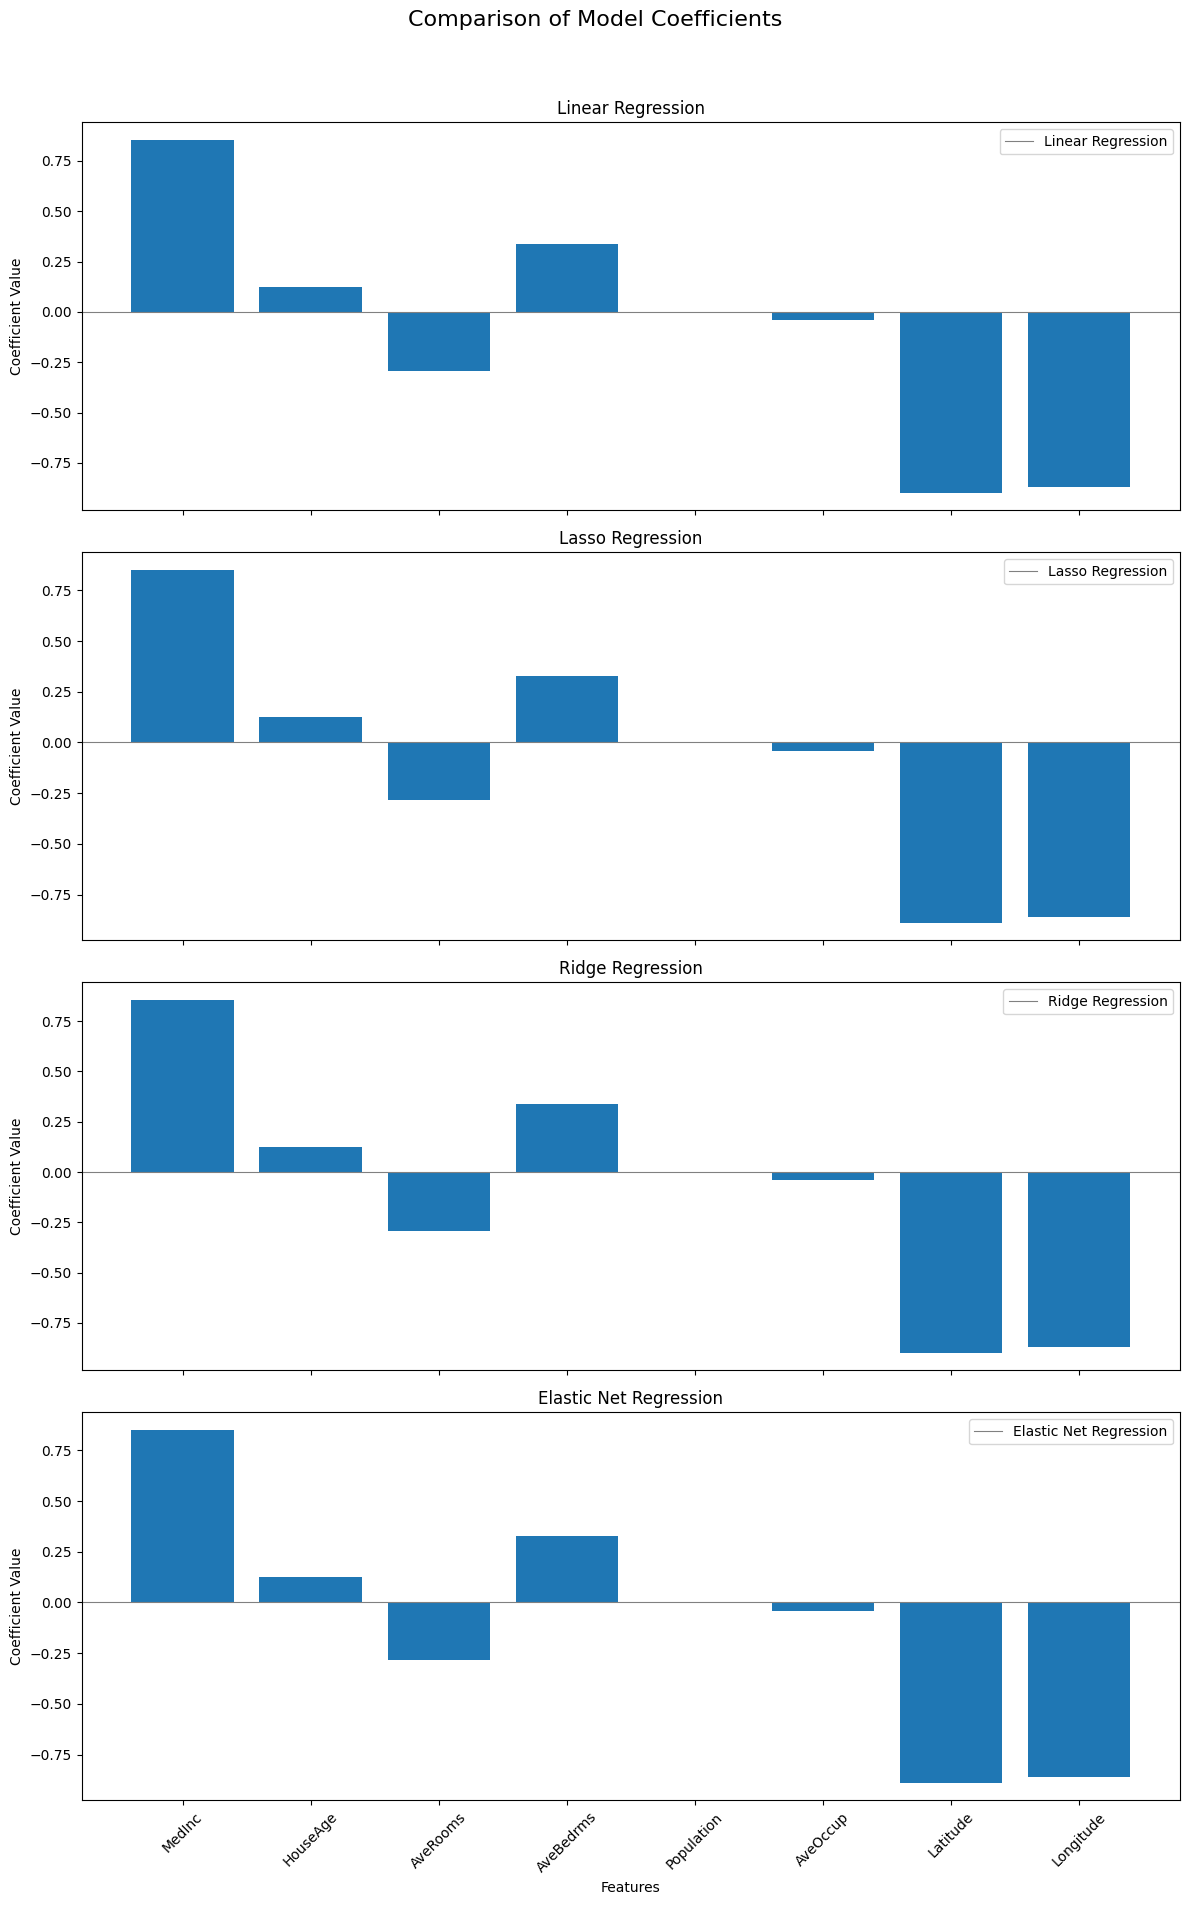

In [10]:
import matplotlib.pyplot as plt

feature_names = X.columns

coefficients = {
    "Linear Regression": linear_model.coef_,
    "Lasso Regression": lasso_model.coef_,
    "Ridge Regression": ridge_model.coef_,
    "Elastic Net Regression": elastic_net_model.coef_
}

# subplots for coefficient visualization
fig, axes = plt.subplots(nrows=len(coefficients), ncols=1, figsize=(12, 20), sharex=True)
fig.suptitle('Comparison of Model Coefficients', fontsize=16)

for i, (name, coefs) in enumerate(coefficients.items()):
    axes[i].bar(feature_names, coefs)
    axes[i].set_title(name)
    axes[i].set_ylabel('Coefficient Value')
    axes[i].axhline(0, color='grey', linewidth=0.8)
    axes[i].legend([name])

#
axes[-1].set_xlabel('Features')
axes[-1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) #
plt.show()


# **Interpretation :**

*   **Optimal Regularization Strengths**:
    *   Lasso: Optimal alpha = 0.0008
    *   Ridge: Optimal alpha = 0.0001
    *   Elastic Net: Optimal alpha = 0.0008, Optimal text{l1_ratio}= 1.00 (behaved like Lasso).
*   **Model Performance Comparison**:
    *   Linear Regression and Ridge Regression: MSE = 0.5559, R2 = 0.5758.
    *   Lasso Regression and Elastic Net Regression: MSE = 0.5548, R2 = 0.5766 (slightly better).
    *   Overall performance differences were marginal on this dataset.
*   **Coefficient Shrinkage and Feature Selection**:
    *   **Linear Regression**: All coefficients non-zero.
    *   **Ridge Regression (L2)**: Coefficients shrunk towards zero but remained non-zero; minimal shrinkage due to low optimal alpha.
    *   **Lasso Regression (L1)**: Some coefficients shrunk exactly to zero, performing feature selection.
    *   **Elastic Net Regression**: Coefficients mirrored Lasso, with some shrunk to zero, consistent with its optimal {l1_ratio}of 1.00.